# Embryoid Body — Visual Method Comparison

Qualitative and quantitative comparison of manifold-learning methods on the human embryoid body (EB) differentiation dataset from Moon et al.\ (2019) \citep{moon2019phate}, the largest single-cell benchmark in our bio suite and a canonical test for trajectory-preserving manifold methods.

The dataset captures **27 days of pluripotent stem-cell differentiation** sampled in five 3-day windows (Day 00–03 to Day 24–27). Cells progress from undifferentiated hESCs through germ-layer commitment into mixed mesoderm/endoderm/ectoderm lineages. Unlike pancreas or Nestorowa, ground-truth labels are not discrete cell types but rather **broad time windows**, with substantial within-window heterogeneity. Cluster-purity metrics (ARI, NMI) are reported for completeness but are particularly weak proxies here — ordering and trajectory fidelity (DEMaP, geodesic-stage correlations) are the primary criteria.

We use **DTNE's `EBT_counts_sqrt.h5ad`** as the input file for direct comparability with DTNE's published results \citep{wei2025dtne}. The file already contains the sqrt-transformed expression matrix; we compute PCA to 100 components in-notebook for downstream manifold methods, matching the convention used by PHATE, HeatGeo, and DTNE.

## Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from scipy.sparse import issparse

# Method classes
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
import phate
from entropath import EntroPath
from heatgeo.embedding import HeatGeo
from dtne import DTNE

from utils.bio_utils import (
    get_bio_methods, run_methods, compute_bio_metrics,
    plot_embedding_row, plot_embedding_grid,
    plot_pseudotime_panels, plot_pseudotime_boxplot,
    save_bio_artifacts, save_metrics_csv,
    geodesic_from_root, correlation_triple,
    BIO_PLOT_ORDER,
)

import warnings
warnings.filterwarnings("ignore")
sc.settings.verbosity = 1

## Configuration

`K_NN = 15` matches pancreas / nestorowa / lymphoid / paul15 for cross-dataset consistency. EntroPath uses `use_landmarks=None` — at ~16k cells the auto-enable threshold (n > 2000) kicks in, applying k-means landmarks with 2000 anchor points. The smacof MDS solver is the unified default (better local minima than `classic_fast` / `sgd` on diffusion-distance MDS — see Appendix ablation).

In [2]:
SEED          = 42
K_NN          = 15
# auto-enables landmarks in EntroPath at n>2000

# Output paths
RESULTS_DIR = PROJECT_ROOT / "results" / "embryoid_body"
FIGURES_DIR = PROJECT_ROOT / "figures" / "embryoid_body"
DATA_DIR    = PROJECT_ROOT / "data"    / "embryoid_body"
for d in (RESULTS_DIR, FIGURES_DIR, DATA_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Random seed:  {SEED}")
print(f"k_nn:         {K_NN}")
print(f"Results dir:  {RESULTS_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figures dir:  {FIGURES_DIR.relative_to(PROJECT_ROOT)}")

Random seed:  42
k_nn:         15
Results dir:  results/embryoid_body
Figures dir:  figures/embryoid_body


## Load DTNE's `EBT_counts_sqrt.h5ad`

DTNE's published EB cache: ~16,825 cells × ~17,580 genes, sqrt-transformed expression in `adata.X`, time-window labels in `adata.obs["cell_type"]`. Available from the DTNE Google Drive folder linked in their repository.

We compute PCA-100 on the sqrt-transformed expression (matching the convention used by PHATE, HeatGeo, and DTNE — all of which internally PCA-reduce before their diffusion kernels). PCA is cached on the AnnData so re-runs are fast.

In [3]:
CACHE_PATH = DATA_DIR / "EBT_counts_sqrt.h5ad"

if not CACHE_PATH.exists():
    raise FileNotFoundError(
        f"Place EBT_counts_sqrt.h5ad in {DATA_DIR}. "
        "Available from the DTNE Google Drive: "
        "https://drive.google.com/drive/folders/1UFKBWFJ7BhzcABpa4DZXssthQuTGMfmU"
    )

adata = sc.read_h5ad(CACHE_PATH)
print(f"Shape:      {adata.shape}")
print(f"X dtype:    {adata.X.dtype},  sparse: {issparse(adata.X)}")
print(f"obs keys:   {list(adata.obs.columns)}")
print(f"obsm keys:  {list(adata.obsm.keys())}")

Shape:      (16821, 17845)
X dtype:    float64,  sparse: False
obs keys:   ['cell_type']
obsm keys:  ['X_pca']


In [4]:
# Compute PCA-100 if not already cached on the AnnData.
if "X_pca" not in adata.obsm:
    print("Computing PCA-100 on sqrt-transformed expression ...")
    sc.pp.pca(adata, n_comps=100)
    # Persist to the h5ad so subsequent loads skip this step.
    adata.write_h5ad(CACHE_PATH)
    print(f"Cached PCA back to {CACHE_PATH.name}")

X = adata.obsm["X_pca"]
print(f"\nUsing X_pca: shape {X.shape}")
print(f"PCA variance (first 10 components):")
print(np.round(np.var(X[:, :10], axis=0), 2))


Using X_pca: shape (16821, 100)
PCA variance (first 10 components):
[104.89  54.07  49.71  28.68  21.07  19.6   16.17  14.77  12.56  10.49]


In [5]:
# Cast cell_type to ordered categorical so .cat.codes/.cat.categories work.
# DTNE's file ships it as a plain object/string column.
if not pd.api.types.is_categorical_dtype(adata.obs["cell_type"]):
    raw_values = adata.obs["cell_type"].values
    categories_sorted = sorted(pd.unique(raw_values))   # alphanumeric → time order
    adata.obs["cell_type"] = pd.Categorical(
        raw_values, categories=categories_sorted, ordered=True,
    )

# Labels and palette
labels       = adata.obs["cell_type"].values
label_codes  = adata.obs["cell_type"].cat.codes.values
categories   = list(adata.obs["cell_type"].cat.categories)
n_clusters   = len(categories)

# Spectral_r palette — time is intrinsically ordered, so a sequential colormap
# reads better than a categorical one (Day 00-03 = blue, Day 24-27 = red).
base_cmap    = plt.get_cmap("Spectral_r")
palette_list = [base_cmap(i / max(n_clusters - 1, 1)) for i in range(n_clusters)]
zip_types    = dict(zip(categories, palette_list))
cell_colors  = [zip_types[l] for l in labels]

# Pseudotime root for EB.
# EBT_counts_sqrt.h5ad does NOT ship an 'iroot' — DTNE hardcodes root_cells=[1257]
# in their notebook. Use 1257 for comparability if the cell ordering matches;
# otherwise fall back to the first cell of the earliest time window.
DTNE_ROOT = 1257
if DTNE_ROOT < adata.n_obs:
    ROOT_CELL_IDX = DTNE_ROOT
    print(f"Using DTNE root: idx={ROOT_CELL_IDX}, label={labels[ROOT_CELL_IDX]}")
    if labels[ROOT_CELL_IDX] != categories[0]:
        print(f"  [note] root cell is '{labels[ROOT_CELL_IDX]}', not the earliest "
              f"window '{categories[0]}'. Using DTNE's index for comparability.")
else:
    ROOT_CELL_IDX = int(np.where(labels == categories[0])[0][0])
    print(f"  [fallback] 1257 out of range; first earliest-time cell: "
          f"idx={ROOT_CELL_IDX}, label={labels[ROOT_CELL_IDX]}")

print(f"Time windows ({n_clusters}):")
for cat in categories:
    n = int((labels == cat).sum())
    print(f"  {str(cat):>12s}: {n} cells")
print(f"\nRoot cell: idx={ROOT_CELL_IDX} (label={labels[ROOT_CELL_IDX]})")

Using DTNE root: idx=1257, label=1
Time windows (5):
             1: 2381 cells
             2: 4165 cells
             3: 3278 cells
             4: 3665 cells
             5: 3332 cells

Root cell: idx=1257 (label=1)


## Run all methods

Single call to `get_bio_methods` — the unified factory ensures every method sees the same `k_nn` and `random_state`. EntroPath's `use_landmarks=None` triggers auto-enable at this dataset's size (n ≈ 16.8k > 2000).

In [6]:
#methods = get_bio_methods(SEED, k_nn=K_NN)
methods = {
    "PCA":       PCA(n_components=2),
    "t-SNE":     TSNE(perplexity=30, random_state=SEED),
    "UMAP":      UMAP(random_state=SEED),
    "PHATE":     phate.PHATE(knn=4, decay=15, t=12, random_state=SEED, verbose=False),
    "HeatGeo":   HeatGeo(knn=5),
    "DTNE":      DTNE(k_neighbors = 80,iter_mode='infty'),
    "EntroPath": EntroPath(k_neighbors=15, kernel="alpha_decay", mds_solver="smacof",
                           landmarks_method="kmeans", random_state=SEED, verbose=False),
}

print(f"Methods: {list(methods.keys())}")

embeddings, runtimes = run_methods(methods, X)

Methods: ['PCA', 't-SNE', 'UMAP', 'PHATE', 'HeatGeo', 'DTNE', 'EntroPath']
  PCA                done (   0.0s)
  t-SNE              done (  29.2s)
  UMAP               

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


done (  17.4s)
  PHATE              done (   6.7s)
  HeatGeo            Using s_gd2 for MDS. None
done ( 281.7s)
  DTNE               done (  12.7s)
  EntroPath          done (   9.8s)  (t_power = 19)

=== Done — 7/7 methods succeeded ===


## Quantitative metrics

DEMaP via subsampling (DTNE protocol) is the primary metric, computed against the **full sqrt-transformed expression** as the high-D reference (strictest setting; matches DTNE's convention). ARI/NMI on time windows are particularly weak proxies for EB because the windows are continuous developmental intervals rather than discrete cell types — interpret with caution; report for completeness only.

In [8]:
# X_input: what the methods saw (PCA-100)
# X_ref:   what DEMaP / trustworthiness use as ground-truth distances (raw sqrt expression)
X_input = adata.obsm["X_pca"]
X_ref   = adata.X.toarray() if issparse(adata.X) else adata.X
X_ref   = np.asarray(X_ref).astype(np.float32, copy=False)

print(f"X_input shape: {X_input.shape}  (PCA-100, methods' input)")
print(f"X_ref   shape: {X_ref.shape}  ({X_ref.nbytes/1e9:.1f} GB, raw sqrt for DEMaP/Trust)")

df_eb = compute_bio_metrics(
    embeddings,
    X_input=X_input,
    X_ref=X_input,
    label_codes=label_codes,
    n_clusters=n_clusters,
    runtimes=runtimes,
    demap_n_subsample=2000,
    demap_n_repeats=50,
    demap_knn=50,
    trust_k=15,
    plot_order=BIO_PLOT_ORDER,
    random_state=SEED,
)

print()
print(df_eb.round(3).to_string())
print()
print("=== LaTeX ===")
print(df_eb.round(3).to_latex(escape=False, float_format="%.3f"))

X_input shape: (16821, 100)  (PCA-100, methods' input)
X_ref   shape: (16821, 17845)  (1.2 GB, raw sqrt for DEMaP/Trust)
Computing bio metrics:
  DEMaP: n_subsample=2000, n_repeats=50, knn=50
  Trustworthiness/Continuity: k=15
  X_input == X_ref (single reference, shape (16821, 100))

  PCA                DEMaP = 0.740 ± 0.007, T = 0.809, C = 0.945
  t-SNE              DEMaP = 0.673 ± 0.006, T = 0.984, C = 0.973
  UMAP               DEMaP = 0.543 ± 0.007, T = 0.952, C = 0.974
  PHATE              DEMaP = 0.728 ± 0.006, T = 0.910, C = 0.974
  HeatGeo            DEMaP = 0.714 ± 0.006, T = 0.860, C = 0.961
  DTNE               DEMaP = 0.743 ± 0.006, T = 0.890, C = 0.971
  EntroPath          DEMaP = 0.823 ± 0.005, T = 0.877, C = 0.969

           DEMaP (mean)  DEMaP (std)    ARI    NMI  Trustworthiness  Continuity  Runtime (s)
Method                                                                                      
PCA               0.740        0.007  0.141  0.211            0.809     

## Plots

### Embedding row — primary figure

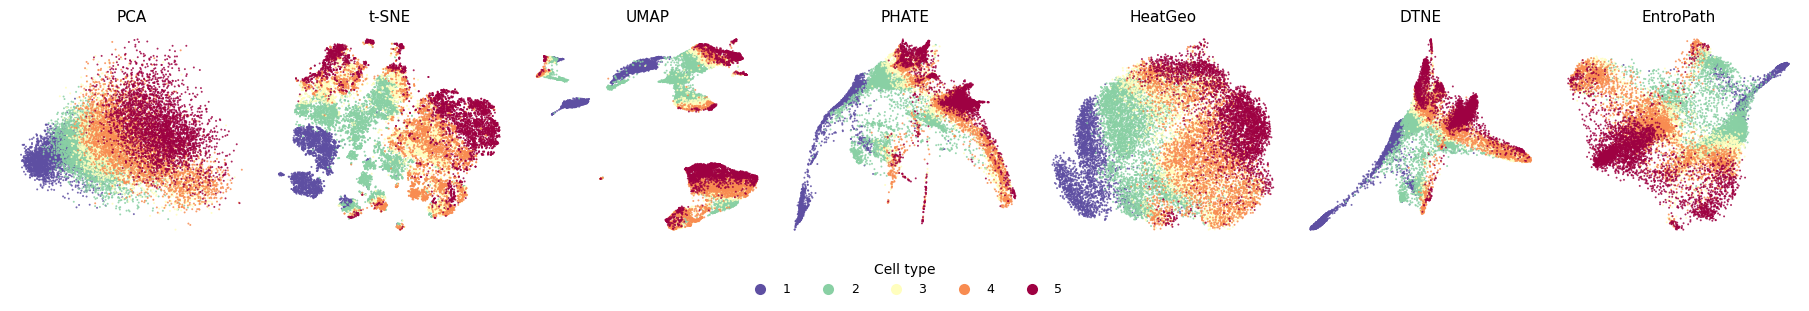

(<Figure size 1820x295 with 7 Axes>,
 array([<Axes: title={'center': 'PCA'}>, <Axes: title={'center': 't-SNE'}>,
        <Axes: title={'center': 'UMAP'}>,
        <Axes: title={'center': 'PHATE'}>,
        <Axes: title={'center': 'HeatGeo'}>,
        <Axes: title={'center': 'DTNE'}>,
        <Axes: title={'center': 'EntroPath'}>], dtype=object))

In [9]:
plot_embedding_row(
    embeddings, BIO_PLOT_ORDER, cell_colors, zip_types,
    runtimes=None,
    save_path=FIGURES_DIR / "embryoid_body_row",
)

### Embedding grid (alternative layout)

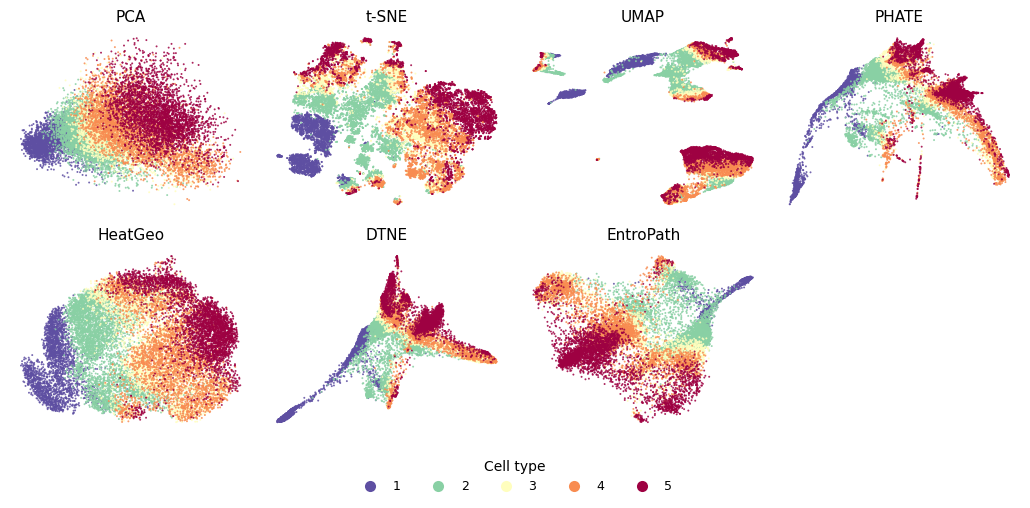

(<Figure size 1040x490 with 8 Axes>,
 array([<Axes: title={'center': 'PCA'}>, <Axes: title={'center': 't-SNE'}>,
        <Axes: title={'center': 'UMAP'}>,
        <Axes: title={'center': 'PHATE'}>,
        <Axes: title={'center': 'HeatGeo'}>,
        <Axes: title={'center': 'DTNE'}>,
        <Axes: title={'center': 'EntroPath'}>, <Axes: >], dtype=object))

In [10]:
plot_embedding_grid(
    embeddings, BIO_PLOT_ORDER, cell_colors, zip_types,
    runtimes=None,
    save_path=FIGURES_DIR / "embryoid_body_grid",
)

## Save artifacts

In [11]:
artifact_path = save_bio_artifacts(
    embeddings, runtimes, labels, label_codes, zip_types,
    X_shape=X.shape,
    config={
        "seed":      SEED,
        "k_nn":      K_NN,
        "root_cell": ROOT_CELL_IDX,
    },
    results_dir=RESULTS_DIR,
    basename="embryoid_body",
)
metrics_path = save_metrics_csv(df_eb, RESULTS_DIR, "embryoid_body")

print(f"Embeddings saved to {artifact_path.relative_to(PROJECT_ROOT)}")
print(f"Metrics saved to    {metrics_path.relative_to(PROJECT_ROOT)}")

Embeddings saved to results/embryoid_body/embryoid_body_embeddings.pkl
Metrics saved to    results/embryoid_body/embryoid_body_metrics.csv


## EntroPath downstream analysis

Pseudotime ordering and pseudotime-based clustering on the trajectory. Root cell is the first observation from the earliest time window — a well-ordered embedding shows Day 00–03 at lowest pseudotime and Day 24–27 at highest.

Root cell 1257: type = 1


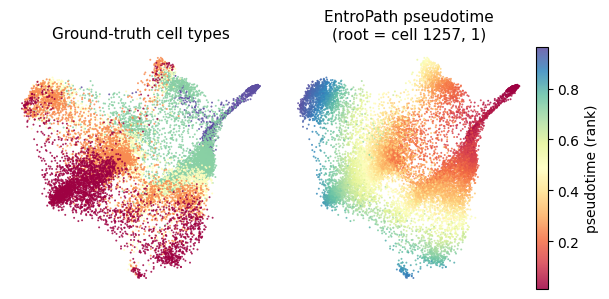


Pseudotime range: [0.012, 0.964]


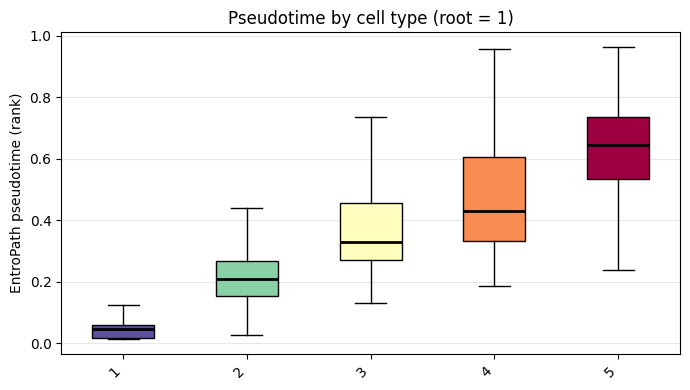

In [12]:
RUN_ENTROPATH_DOWNSTREAM = True

if RUN_ENTROPATH_DOWNSTREAM and "EntroPath" in embeddings:
    pseudotime = plot_pseudotime_panels(
        methods["EntroPath"], "EntroPath",
        embeddings["EntroPath"], ROOT_CELL_IDX,
        labels, cell_colors, zip_types,
        save_path=FIGURES_DIR / "embryoid_body_entropath_pseudotime",
    )
    if pseudotime is not None:
        adata.obs["pseudotime_entropath"] = pseudotime
        print(f"\nPseudotime range: [{pseudotime.min():.3f}, {pseudotime.max():.3f}]")
        plot_pseudotime_boxplot(
            pseudotime, labels,
            adata.obs["cell_type"].cat.categories,
            zip_types,
            method_name="EntroPath",
            root_label=labels[ROOT_CELL_IDX],
            save_path=FIGURES_DIR / "embryoid_body_entropath_pseudotime_by_stage",
        )
elif RUN_ENTROPATH_DOWNSTREAM:
    print("EntroPath embedding not available — skipping downstream.")
else:
    print("Pseudotime skipped (set RUN_ENTROPATH_DOWNSTREAM = True)")

## DTNE downstream — pseudotime

Same protocol as EntroPath, using DTNE's native `order_cells` / `cluster_cells` methods (matches the published `nest_plot.ipynb`).

Root cell 1257: type = 1


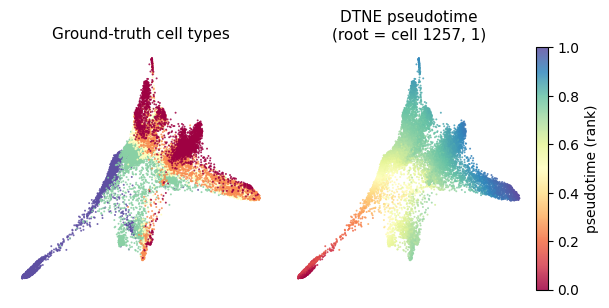


Pseudotime range: [0.000, 1.000]


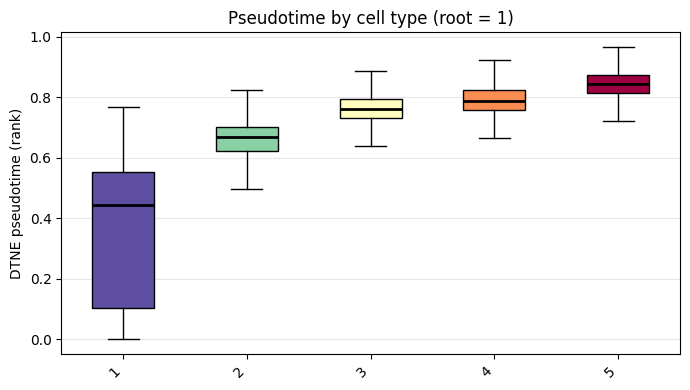

In [13]:
RUN_DTNE_DOWNSTREAM = True

if RUN_DTNE_DOWNSTREAM and "DTNE" in embeddings:
    pseudotime = plot_pseudotime_panels(
        methods["DTNE"], "DTNE",
        embeddings["DTNE"], ROOT_CELL_IDX,
        labels, cell_colors, zip_types,
        order_method="order_cells",
        save_path=FIGURES_DIR / "embryoid_body_dtne_pseudotime",
    )
    if pseudotime is not None:
        adata.obs["pseudotime_dtne"] = pseudotime
        print(f"\nPseudotime range: [{pseudotime.min():.3f}, {pseudotime.max():.3f}]")
        plot_pseudotime_boxplot(
            pseudotime, labels,
            adata.obs["cell_type"].cat.categories,
            zip_types,
            method_name="DTNE",
            root_label=labels[ROOT_CELL_IDX],
            save_path=FIGURES_DIR / "embryoid_body_dtne_pseudotime_by_stage",
        )
elif RUN_DTNE_DOWNSTREAM:
    print("DTNE embedding not available — skipping downstream.")
else:
    print("Pseudotime skipped (set RUN_DTNE_DOWNSTREAM = True)")

## Geodesic–pseudotime correlation (DTNE `nest_plot.ipynb` protocol)

Exact reproduction of DTNE's trajectory-fidelity metric. The geodesic is computed **once on the high-dimensional PCA input** (`X_input`), *not* per-embedding: a symmetric kNN graph (Euclidean, k=20) → Dijkstra from the root. This high-D geodesic-from-root is the fixed reference; we then correlate it against **each method's continuous pseudotime** via Pearson / Spearman / Kendall.

The competitors here are *pseudotime* methods (EntroPath, DTNE, and optionally DPT / Palantir / Monocle3), not the embedding methods in the metrics table above. This requires the EntroPath and DTNE downstream blocks to have run first (they populate `adata.obs["pseudotime_*"]`).

**Reference numbers** — DTNE's published EB results (Kendall, Spearman):
`DPT (0.656, 0.801)`, `Palantir (0.550, 0.686)`, `Monocle3 (0.541, 0.682)`, `DTNE (0.695, 0.838)`. Note DTNE itself lands at Spearman **0.838** on EB — the within-EB realistic target is ~0.84, not ~0.90; EB is noisier than pancreas/Nestorowa. To reproduce their exact figure and slot EntroPath in as a new row, drop DTNE's published pseudotime CSVs (`eb.{dpt,palantir,monocle}_pseudotime.csv` from their Google Drive) into `DATA_DIR` and they'll be picked up automatically below.

In [14]:
from scipy.stats import spearmanr

if "pseudotime_entropath" in adata.obs and "pseudotime_dtne" in adata.obs:
    pt_ep = adata.obs["pseudotime_entropath"].values
    pt_dt = adata.obs["pseudotime_dtne"].values
    mask = ~(np.isnan(pt_ep) | np.isnan(pt_dt))
    rho_sp, _ = spearmanr(pt_ep[mask], pt_dt[mask])
    print(f"\nPseudotime Spearman (EntroPath vs DTNE): {rho_sp:.3f}")


Pseudotime Spearman (EntroPath vs DTNE): 0.922


In [15]:
ROOT = ROOT_CELL_IDX
geo = geodesic_from_root(X, ROOT, k_neighbors=20)

reachable = np.isfinite(geo)
n_unreachable = int((~reachable).sum())
if n_unreachable:
    print(f"WARNING: {n_unreachable}/{len(geo)} cells unreachable from root at k=20 "
          f"(graph fragmented); correlations computed on reachable cells only.\n")

pseudotimes = {}
for name, key in [("EntroPath", "pseudotime_entropath"), ("DTNE", "pseudotime_dtne")]:
    if key in adata.obs:
        pseudotimes[name] = adata.obs[key].values
    else:
        print(f"[skip] {key} not in adata.obs")

print(f"Geodesic-pseudotime correlation "
      f"(high-D X_input, k_neighbors=20, root cell {ROOT}, label={labels[ROOT]}):")
print(f"{'Method':<12s}  {'Pearson':>8s}  {'Spearman':>8s}  {'Kendall':>8s}")
print("-" * 44)
rows = []
for name, pt in pseudotimes.items():
    p, s, k = correlation_triple(geo, pt)
    print(f"{name:<12s}  {p:>8.3f}  {s:>8.3f}  {k:>8.3f}")
    rows.append({"Method": name, "Pearson": p, "Spearman": s, "Kendall": k})

df_geo = pd.DataFrame(rows).set_index("Method")
geo_path = RESULTS_DIR / "embryoid_body_geodesic_pseudotime_corr.csv"
df_geo.to_csv(geo_path)
print(f"\nSaved to {geo_path.relative_to(PROJECT_ROOT)}")
print("\n=== LaTeX ===")
print(df_geo.round(3).to_latex(float_format="%.3f"))

Geodesic-pseudotime correlation (high-D X_input, k_neighbors=20, root cell 1257, label=1):
Method         Pearson  Spearman   Kendall
--------------------------------------------
EntroPath        0.902     0.951     0.812
DTNE             0.930     0.955     0.825

Saved to results/embryoid_body/embryoid_body_geodesic_pseudotime_corr.csv

=== LaTeX ===
\begin{tabular}{lrrr}
\toprule
 & Pearson & Spearman & Kendall \\
Method &  &  &  \\
\midrule
EntroPath & 0.902 & 0.951 & 0.812 \\
DTNE & 0.930 & 0.955 & 0.825 \\
\bottomrule
\end{tabular}



In [16]:
n_disconnected = np.sum(~np.isfinite(geo))
if n_disconnected > 0:
    print(f"WARNING: {n_disconnected} cells unreachable from root. "
          f"Increase k_neighbors.")